In [1]:
#LOADING MAIN LIBRARIES
import xarray as xr
import numpy as np
import matplotlib
# matplotlib.use("Agg") #figures are not sent to the Jupyter frontend #*#* (turn off if wanting to see plots in Notebook)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from tqdm import tqdm

import os

In [2]:
#SETTING UP MAIN DIRECTORIES
mainDirectory = "/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/"

In [3]:
#DIRECTORY FUNCTIONS
def ListFiles(directory, n=10):
    files = os.listdir(directory)
    # print("Listing first", n, "files:\n", files[:n], "\n")
    return files

In [4]:
#LOADING CLASSES
# --- Add your Functions folder to sys.path ---
import sys
path = mainDirectory + '/Functions_2.0/Classes'
sys.path.append(path)

# --- Import all your function modules ---
import importlib
modules = [
    "Classes_MapPlotting"
]

for mod in modules:
    globals()[mod] = importlib.import_module(mod)        # import module itself
    globals().update(vars(globals()[mod]))              # import all functions into global namespace

In [5]:
################################################################################

In [6]:
#DATA DESCRIPTIONS

### Data Type
# C-Band Scanning ARM Precipitation Radar (CSAPR2)

### DOI (Permanent Link)
# https://armgov.svcs.arm.gov/capabilities/instruments/csapr

### Summary
# The C-Band Scanning ARM Precipitation Radar is a dual-polarization 
# Doppler weather radar that operates in a simultaneous transmit
# and receive (STAR) mode, splitting the transmit signal so that power
# is transmitted on both horizontal and vertical polarizations at the same time. 
# The CSAPR can also transmit on a single polarization (horizontal or vertical) 
# and measure linear depolarization ratio (LDR).

### Temporal Coverage

### Spatial Coverage

In [16]:
import math

def bounding_box(lat, lon, dist_km):
    """
    Compute bounding box corners around (lat, lon), extending dist_km in each direction,
    using Earth radius (no 111-km approximation).

    Parameters
    ----------
    lat : float
        Latitude in degrees (positive north).
    lon : float
        Longitude in degrees (positive east; negative for west).
    dist_km : float
        Distance in kilometers to extend in each direction.

    Returns
    -------
    dict
        Dictionary with keys 'SW', 'SE', 'NE', 'NW' and (lat, lon) tuples.
    """
    R = 6371.0  # Earth radius in km
    
    # Convert to radians
    lat_rad = math.radians(lat)
    
    # Degree offsets
    dlat = (dist_km / R) * (180 / math.pi)
    dlon = (dist_km / (R * math.cos(lat_rad))) * (180 / math.pi)
    
    corners = {
        "SW": (lat - dlat, lon - dlon),
        "SE": (lat - dlat, lon + dlon),
        "NE": (lat + dlat, lon + dlon),
        "NW": (lat + dlat, lon - dlon),
    }
    return corners

# Example
lat0, lon0 = 29.532, -95.284
corners = bounding_box(lat0, lon0, 250)
for name, coords in corners.items():
    print(f"{name}: {coords}")


SW: (27.283695985203174, -97.86801827645755)
SE: (27.283695985203174, -92.69998172354246)
NE: (31.780304014796826, -92.69998172354246)
NW: (31.780304014796826, -97.86801827645755)


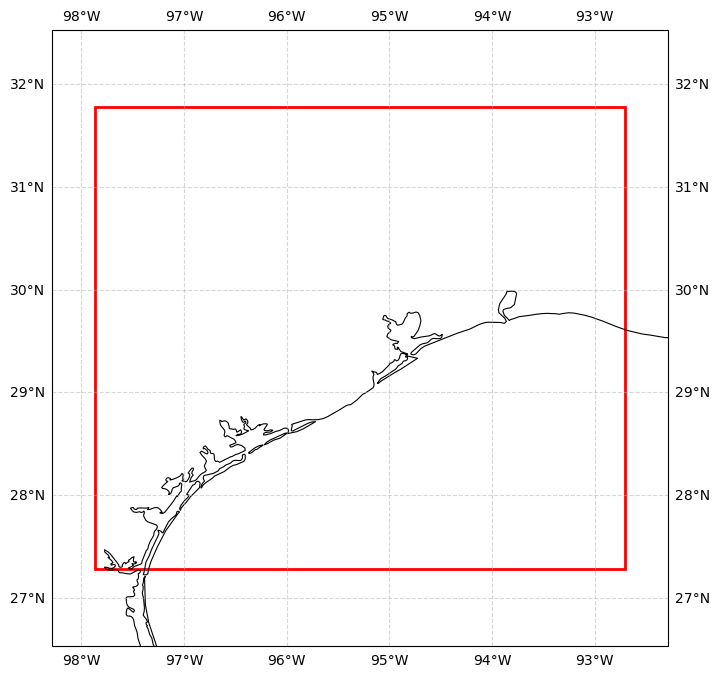

In [17]:
mapPlotting = MapPlotting(
    sw_corner=(27.28, -97.87),  # (lat_min, lon_min)
    ne_corner=(31.78, -92.70),  # (lat_max, lon_max)
    delta=3,
    fontsize=7
)
mapPlotting.PlotBoundingBox()

In [14]:
################################################################################

In [44]:
#SET UP DIRECTORIES
Campaign="TRACER"
DataType="XBand_Radar"
RadarType="PPIV"

#Code Directory
Code_Directory="/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data"
Code_Directory=os.path.join(Code_Directory,Campaign)
print("Code Directory Set as:", Code_Directory, '\n')

def GetDataDirectory(Campaign=Campaign,
                     DataType=DataType,
                     RadarType=RadarType,
                     BaseDir="/glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data",
                    ):
                     
                     
    #old base directory: BaseDir="/glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data"
    Data_Directory = os.path.join(BaseDir, Campaign, DataType, RadarType.lower()) 
    #SUR is the same as PPI (Plan Position Indicator) radar, RHI is Range-Height-Indicator
    print("Data Directory Set as:", Data_Directory, '\n')
    FileList = np.sort(ListFiles(Data_Directory))
    return Data_Directory, FileList
# Data_Directory, FileList=GetDataDirectory(RadarType="PPIV") #hsrhi  ppi vpt
# Data_Directory, FileList=GetDataDirectory(RadarType="HSRHI") #hsrhi  ppi vpt

#Output Directory
Output_Directory="/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data"
Output_Directory=os.path.join(Output_Directory,Campaign,DataType)

Code Directory Set as: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data/TRACER 

Data Directory Set as: /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/TRACER/XBand_Radar/ppiv 



In [10]:
#READING DATA
###################################
#how to unzip in terminal
# mkdir -p unzip
# for f in *.tar; do
#     tar -xvf "$f" -C unzip
# done

In [11]:
def GetData(Data_Directory, FileList, index):
    DataFile = os.path.join(Data_Directory,FileList[index])
    print(f"Downloading File:\n {DataFile}","\n")
    DataNC = xr.open_dataset(DataFile,decode_timedelta=True)
    return DataNC, DataFile

In [12]:
# Citing Py-ART (Toolkit for interpolating and plotting radar data (PPI and RHI)
# If you use Py-ART in your work please cite it in your paper. While the developers appreciate mentions in the text and acknowledgements citing the paper helps more.

# For Py-ART cite our paper in the Journal of Open Research Software

# Helmus, J.J. & Collis, S.M., (2016). The Python ARM Radar Toolkit (Py-ART), a Library for Working with Weather Radar Data in the Python Programming Language. Journal of Open Research Software. 4(1), p.e25. DOI: http://doi.org/10.5334/jors.119

# For a general citation on Open Radar Software please cite Maik Heistermann in BAMS

# M. Heistermann, S. Collis, M. J. Dixon, S. Giangrande, J. J. Helmus, B. Kelley, J. Koistinen, D. B. Michelson, M. Peura, T. Pfaff, and D. B. Wolff, 2015: The Emergence of Open-Source Software for the Weather Radar Community. Bull. Amer. Meteor. Soc. 96, 117–128, doi: 10.1175/BAMS-D-13-00240.1.


In [73]:
import os
import pyart
import matplotlib.pyplot as plt
import numpy as np
from pyart.map import grid_from_radars


def combine_radars_from_files(file_list):
    """Reads a list of radar files and combines them into a single Radar object."""
    if not file_list:
        return None
    combined_radar = pyart.io.read(file_list[0])
    for filename in file_list[1:]:
        print(f"Joining {os.path.basename(filename)}...")
        next_radar = pyart.io.read(filename)
        combined_radar = pyart.util.join_radar(combined_radar, next_radar)
    return combined_radar


class RadarScan:
    def __init__(self, RadarType="PPIV", date="20220630",
                 start_time="00:00:00", interval_sec=15):
        """
        Initialize a RadarScan object using Py-ART.

        Parameters
        ----------
        RadarType : str
            Radar type (PPIV, PPI, etc.).
        date : str
            Date string in YYYYMMDD format.
        start_time : str
            Starting timestamp (HH:MM:SS).
        interval_sec : int
            Interval length (seconds).
        """
        self.Data_Directory, self.FileList = GetDataDirectory(RadarType=RadarType)
        self.FileList = [f for f in self.FileList if date in f]
        if not self.FileList:
            raise FileNotFoundError(f"No radar files found for date {date}")

        # Select files in requested time window
        self.FileList = self._filter_files_by_time(self.FileList, start_time, interval_sec)
        if not self.FileList:
            raise FileNotFoundError(f"No files found between {start_time} and +{interval_sec}s on {date}")

        self.DataFiles = [os.path.join(self.Data_Directory, f) for f in self.FileList]
        self.DataName = f"{RadarType}_{date}_{start_time}_{interval_sec}s ({len(self.DataFiles)} files)"

        # Combine files
        print("Combining Sweep Files: ",self.DataFiles)
        self.radar = combine_radars_from_files(self.DataFiles)

        # Extract info
        self._extract_metadata()
        self._extract_variables()
        self._get_PyArt_colormaps()

    # -------------------------------
    # Helpers
    # -------------------------------
    def _time_to_seconds(self, timestr):
        h, m, s = map(int, timestr.split(":"))
        return h*3600 + m*60 + s

    def _file_seconds(self, fname):
        timestr = fname.split(".")[-2]  # e.g., 000822
        hh, mm, ss = int(timestr[0:2]), int(timestr[2:4]), int(timestr[4:6])
        return hh*3600 + mm*60 + ss

    def _filter_files_by_time(self, file_list, start_time, interval_sec):
        start_sec = self._time_to_seconds(start_time)
        end_sec = start_sec + interval_sec
        return [f for f in file_list
                if start_sec <= self._file_seconds(f) <= end_sec]

    # -------------------------------
    # Metadata and fields
    # -------------------------------
    def _extract_metadata(self):
        self.radar_latitude  = float(self.radar.latitude['data'][0])
        self.radar_longitude = float(self.radar.longitude['data'][0])
        self.radar_altitude  = float(self.radar.altitude['data'][0])
        self.nt = self.radar.nrays
        self.nr = self.radar.ngates
        self.nsweeps = self.radar.nsweeps
        self.elevations = self.radar.fixed_angle['data']  # tilt angles
        self.times      = self.radar.time['data']
        self.ranges     = self.radar.range['data']
        self.azimuths   = self.radar.azimuth['data']
        self.TimeRange  = (self.times[0], self.times[-1])

    def _extract_variables(self):
        if "reflectivity" in self.radar.fields:
            self.reflectivity = self.radar.fields["reflectivity"]["data"]
        else:
            raise KeyError("Reflectivity field not found in radar file.")

    def _get_PyArt_colormaps(self):
        self.cmap_reflectivity = pyart.config.get_field_colormap("reflectivity")

    # -------------------------------
    # Public
    # -------------------------------
    def summary(self):
        print(f"Radar dataset: {self.DataName}")
        print(f"Radar location: ({self.radar_latitude:.4f}, "
              f"{self.radar_longitude:.4f}, {self.radar_altitude:.1f} m)")
        print(f"Sweeps: {self.nsweeps}")
        print(f"Elevation angles: {self.elevations}")
        print(f"Reflectivity shape: {self.reflectivity.shape}")
        print(f"Time range (s): {self.TimeRange}")

    def PlotReflectivityAllSweeps(self, vmin=-10, vmax=60):
        """Plot each tilt in its own subplot (good for PPIV)."""
        display = pyart.graph.RadarDisplay(self.radar)
        n = self.nsweeps
        ncols = 3
        nrows = int(np.ceil(n / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 5*nrows))
        axes = axes.flatten()
        for sweep in range(n):
            display.plot_ppi('reflectivity', sweep=sweep,
                             vmin=vmin, vmax=vmax,
                             cmap=self.cmap_reflectivity,
                             ax=axes[sweep], colorbar_flag=True)
            elev = self.elevations[sweep]
            axes[sweep].set_title(f"Sweep {sweep} ({elev:.1f}°)")
            axes[sweep].set_aspect("equal")
        for ax in axes[n:]:
            ax.set_visible(False)
        plt.tight_layout()
        plt.show()

    def PlotCAPPI(self, level=2000, vmin=-10, vmax=60): #Barnes interpolation (a type of distance-weighted scheme) to map irregular polar radar coordinates onto the Cartesian grid
        """Make a constant-altitude plan position indicator (CAPPI)."""
        grid = grid_from_radars(
            self.radar,
            grid_shape=(41, 201, 201),  # z,y,x
            grid_limits=((0, 20000), (-100000, 100000), (-100000, 100000)),
            fields=['reflectivity']
        )
        z_levels = grid.z['data']
        level_idx = np.argmin(np.abs(z_levels - level))
        refl = grid.fields['reflectivity']['data'][level_idx]
        x = grid.x['data']/1000.0
        y = grid.y['data']/1000.0
        fig, ax = plt.subplots(figsize=(7,6))
        pcm = ax.pcolormesh(x, y, refl, cmap=self.cmap_reflectivity,
                            vmin=vmin, vmax=vmax)
        plt.colorbar(pcm, ax=ax, label="Reflectivity (dBZ)")
        ax.set_xlabel("x (km)")
        ax.set_ylabel("y (km)")
        ax.set_title(f"CAPPI Reflectivity at {z_levels[level_idx]:.0f} m")
        ax.set_aspect("equal")
        plt.show()

    def PlotRHI(self, sweep=0, vmin=-10, vmax=60):
        """Plot an RHI sweep (vertical slice at fixed azimuth)."""
        display = pyart.graph.RadarDisplay(self.radar)
        fig, ax = plt.subplots(figsize=(8, 6))

        display.plot_rhi(
            'reflectivity',
            sweep=sweep,
            vmin=vmin, vmax=vmax,
            cmap=self.cmap_reflectivity,
            ax=ax,
            colorbar_label='Reflectivity (dBZ)'
        )

        # In RHIs, fixed_angle is the azimuth
        az = self.radar.fixed_angle['data'][sweep]
        ax.set_title(f"RHI Reflectivity – Sweep {sweep} (Azimuth {az:.1f}°)")
        plt.show()



Data Directory Set as: /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/TRACER/XBand_Radar/ppiv 

Combining Sweep Files:  ['/glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/TRACER/XBand_Radar/ppiv/houxsacrcfrqcM1.b1.20220701.162936.nc']
Radar dataset: PPIV_20220701_16:29:36_15s (1 files)
Radar location: (29.6700, -95.0590, 8.0 m)
Sweeps: 1
Elevation angles: [1.9995422]
Reflectivity shape: (799, 1539)
Time range (s): (59376.000788, 59508.378823)


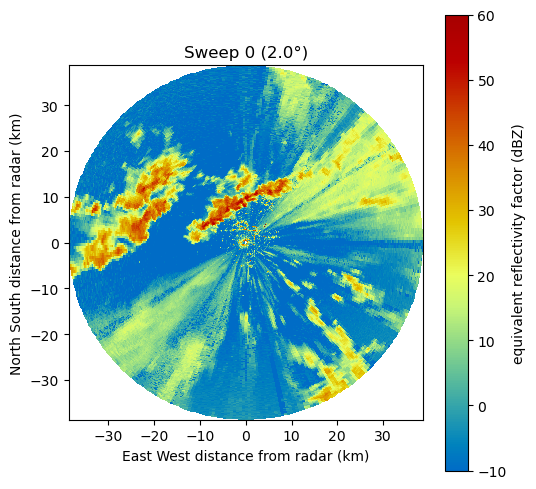

In [76]:
# Matches the file houxsacrcfrqcM1.b1.20220701.162936.nc
scan = RadarScan(
    RadarType="PPIV",
    date="20220701",
    start_time="16:29:36",   # <-- match file timestamp
    interval_sec=15
)
scan.summary()

scan.PlotReflectivityAllSweeps()


Data Directory Set as: /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/TRACER/XBand_Radar/hsrhi 

Combining Sweep Files:  ['/glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/TRACER/XBand_Radar/hsrhi/houxsacrcfrqcM1.b1.20220701.163506.nc']
Radar dataset: HSRHI_20220701_16:35:06_15s (1 files)
Radar location: (29.6700, -95.0590, 8.0 m)
Sweeps: 6
Elevation angles: [  0.  30.  60.  90. 120. 150.]
Reflectivity shape: (1255, 1539)
Time range (s): (59706.904154, 59914.926949)


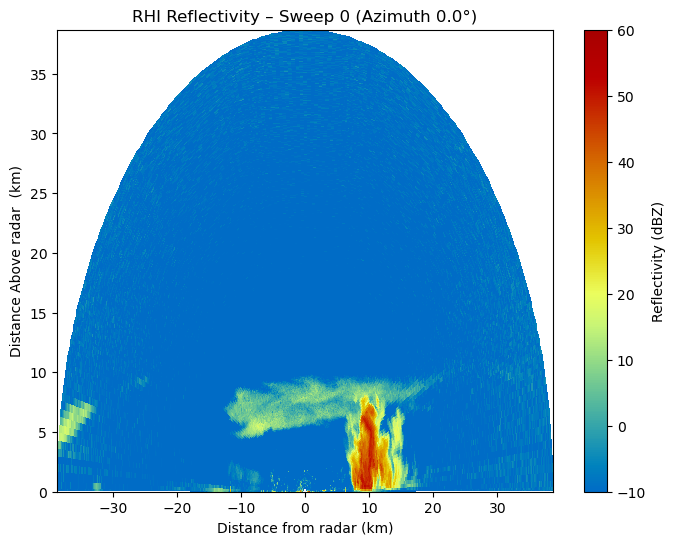

In [77]:
scan = RadarScan(RadarType="HSRHI", date="20220701", start_time="16:35:06", interval_sec=15)
scan.summary()

scan.PlotRHI(sweep=0)

In [ ]:
##########################################################
#TESTING

In [163]:
# # TRYIGN TO CALCULATE MYSELF (==> USE PYART by ARM INSTEAD)
# import os
# import numpy as np
# import xarray as xr
# import matplotlib.pyplot as plt

# class RadarScan:
#     def __init__(self, RadarType="PPI", index=0):
#         """
#         Initialize a RadarScan object.

#         Parameters
#         ----------
#         RadarType : str
#             Radar type (e.g., 'PPI', 'RHI', 'HSRHI', 'VPT').
#         index : int
#             Index of the file in the file list.
#         """
#         # Use your helper functions
#         self.Data_Directory, self.FileList = GetDataDirectory(RadarType=RadarType)
#         self.DataNC, self.DataFile = GetData(self.Data_Directory, self.FileList, index=index)
#         self.DataName = os.path.basename(self.DataFile)

#         # Extract metadata & variables
#         self._extract_metadata()
#         self._extract_variables()
#         self._get_PyArt_colormaps()
#         self._compute_cartesian()
#         self._compute_latlon()

#         # Close dataset (arrays remain in memory)
#         self.DataNC.close()

#     def _extract_metadata(self):
#         # Radar site location
#         self.radar_latitude = float(self.DataNC["latitude"].values)
#         self.radar_longitude = float(self.DataNC["longitude"].values)
#         self.radar_altitude = float(self.DataNC["altitude"].values)

#         # Dimensions
#         self.nt = self.DataNC.sizes["time"]   # rays
#         self.nr = self.DataNC.sizes["range"]  # gates

#         # Coordinates
#         self.times = self.DataNC["time"].values         # shape (nt,)
#         self.ranges = self.DataNC["range"].values       # shape (nr,)
#         self.azimuths = self.DataNC["azimuth"].values   # shape (nt,)
#         self.elevations = self.DataNC["elevation"].values  # shape (nt,)

#         # Convenience time info
#         self.TimeRange = (self.times[0], self.times[-1])

#     def _extract_variables(self):
#         # Reflectivity [ray, gate]
#         self.reflectivity = self.DataNC["reflectivity"].values  # shape (nt, nr)

#     def _get_PyArt_colormaps(self):
#         import pyart
#         self.cmap_reflectivity = pyart.config.get_field_colormap("reflectivity")

#     def _compute_cartesian(self):
#         """
#         Compute Cartesian coordinates (x,y) for all rays in a sweep.
#         """
#         # Rays = rows, ranges = columns
#         r, theta = np.meshgrid(self.ranges, np.deg2rad(self.azimuths))
#         self.x = r * np.sin(theta)   # east-west [m]
#         self.y = r * np.cos(theta)   # north-south [m]

#     def _compute_latlon(self):
#         """
#         Convert Cartesian (x,y) offsets to latitude/longitude.
#         """
#         R = 6.371e6  # Earth radius [m]
#         dLat = (self.y / R) * (180 / np.pi)
#         dLon = (self.x / (R * np.cos(np.deg2rad(self.radar_latitude)))) * (180 / np.pi)

#         self.Latitude = self.radar_latitude + dLat
#         self.Longitude = self.radar_longitude + dLon

#     def summary(self):
#         print(f"Radar file: {self.DataName}")
#         print(f"Time range: {self.TimeRange[0]} to {self.TimeRange[1]}")
#         print(f"Radar location: ({self.radar_latitude:.4f}, {self.radar_longitude:.4f}, {self.radar_altitude:.1f} m)")
#         print(f"Reflectivity shape: {self.reflectivity.shape} (rays, gates)")
#         print(f"Lat/Lon grid shape: {self.Latitude.shape}")

#     def PlotReflectivity(self, sweep_title=None, vmin=-10, vmax=60):
#         """
#         Plot a full PPI sweep (all azimuths in the file).
#         """
#         fig, ax = plt.subplots(figsize=(6, 6))

#         cs = ax.contourf(
#             self.Longitude, self.Latitude, self.reflectivity,
#             levels=np.linspace(vmin, vmax, 30),
#             cmap=self.cmap_reflectivity, vmin=vmin, vmax=vmax
#         )
#         plt.colorbar(cs, ax=ax, label="Reflectivity (dBZ)")

#         ax.set_xlabel("Longitude")
#         ax.set_ylabel("Latitude")
#         ax.set_aspect("equal")

#         # Mark radar location
#         ax.plot(self.radar_longitude, self.radar_latitude, "o",
#                 color="black", markersize=8)

#         # Title
#         if sweep_title is None:
#             sweep_title = f"PPI Reflectivity\nStart {self.times[0]} End {self.times[-1]}"
#         ax.set_title(sweep_title, fontsize=12)
#         plt.show()
